# Table of Contents
1. [Project Overview](#1.-Project-Overview)
2. [Data Loading](#2.-Data-Loading)
3. [Stratified split](#3.-Stratified-split)
4. [Adjusted Ratios: Full vs Log Model](#4.-Adjusted-Ratios-Full-vs-Log-Model)
5. [Feature reduction](#5.-Feature-reduction)
6. [Model comparison with cross-validation](#6.-Model-comparison-with-cross-validation)

## 1. Project Overview

This notebook presents a modeling workflow using logistic regression to analyze the relationship between a set of predictors and a binary outcome variable.

The analysis focuses on building interpretable statistical models, evaluating their performance, and comparing different model specifications. Special attention is given to feature reduction and model stability using cross-validation.

The notebook follows a structured data science workflow: data preparation, model fitting, feature selection, and model evaluation.

# 2. Data Loading

In [10]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import sys
from pathlib import Path
from ucimlrepo import fetch_ucirepo
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
#Custome
sys.path.append(str(Path.cwd().parent / "src"))
from clinical_risk.inference import (rank_biserial,
                                    categorical_test)
from clinical_risk.utils import add_log_features
from clinical_risk.modeling import (fit_logit_model,
                                    logistic_or_summary,
                                    logit_model_metrics,
                                    predict_logit,
                                    evaluate_classifier,
                                    cross_validate_logit,
                                    backward_elimination_aic)
from clinical_risk.plotting import (plot_roc_curves,plot_forest_or_on_ax)


sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


seed = 891
random.seed(seed)
np.random.seed(seed)

In [11]:
data = fetch_ucirepo(id=519)

X = data.data.features.copy()
y = data.data.targets.squeeze().copy()   # convertir a Series
df = pd.concat([X, y], axis=1)

#Cols
binary_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]
transform_vars = ["serum_creatinine", "creatinine_phosphokinase"]
full_vars = X.columns.to_list()

print("Shape:", df.shape)
print("Outcome mean:", y.mean().round(3))

Shape: (299, 13)
Outcome mean: 0.321


# 3. Stratified split

In [12]:
#Transform to log
X = add_log_features(X, transform_vars, remove = False)
numeric_cols = [col for col in X.columns if col not in binary_cols]

# scaled df
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X = sm.add_constant(X)

# Sampling Stratification. Model A
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=seed
)

log_vars = [c for c in X.columns if c not in transform_vars]

# 4. Adjusted Ratios: Full vs Log Model

In [13]:
model = fit_logit_model(X_train[full_vars],y_train)
model_log = fit_logit_model(X_train[log_vars],y_train)

OR_model = logistic_or_summary(model)
OR_model_log = logistic_or_summary(model_log)

models = {"model": model,"model_log": model_log}
results = pd.DataFrame([{"model": name, **logit_model_metrics(m)} for name, m in models.items()])
results

,model,n_obs,log_likelihood,AIC,pseudo_R2_McFadden
0,model,239,-86.313001,198.626003,0.425389
1,model_log,239,-85.542455,197.084909,0.430519


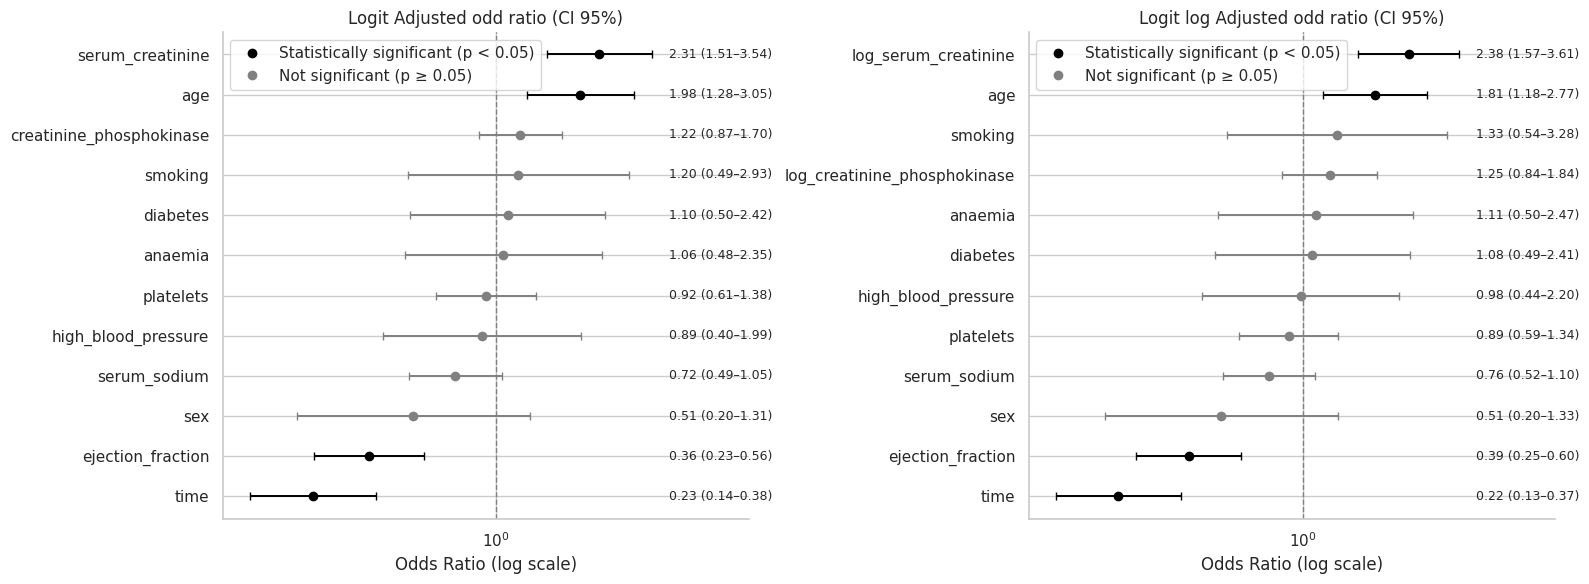

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)
plot_forest_or_on_ax(axes[0], OR_model, title="Logit Adjusted odd ratio (CI 95%)")
plot_forest_or_on_ax(axes[1], OR_model_log, title="Logit log Adjusted odd ratio (CI 95%)")
sns.despine()
plt.tight_layout()
plt.show()

# 5. Feature reduction

In [6]:
# X_train e y_train ya definidos en tu fase 4
backward_result = backward_elimination_aic(X_train, y_train, verbose=True)
selected_vars = backward_result["selected_variables"]
model_reduced = backward_result["model"]
OR_model_reduced  = logistic_or_summary(model_reduced)
print("Variables seleccionadas:")
print(selected_vars)

Removing 'high_blood_pressure' improves AIC: 200.512 -> 198.512
Removing 'log_creatinine_phosphokinase' improves AIC: 198.512 -> 196.552
Removing 'serum_creatinine' improves AIC: 196.552 -> 194.591
Removing 'diabetes' improves AIC: 194.591 -> 192.653
Removing 'anaemia' improves AIC: 192.653 -> 190.767
Removing 'platelets' improves AIC: 190.767 -> 189.063
Removing 'smoking' improves AIC: 189.063 -> 187.322
Removing 'creatinine_phosphokinase' improves AIC: 187.322 -> 186.791
Removing 'sex' improves AIC: 186.791 -> 186.081
Removing 'serum_sodium' improves AIC: 186.081 -> 186.066
Variables seleccionadas:
['const', 'age', 'ejection_fraction', 'time', 'log_serum_creatinine']


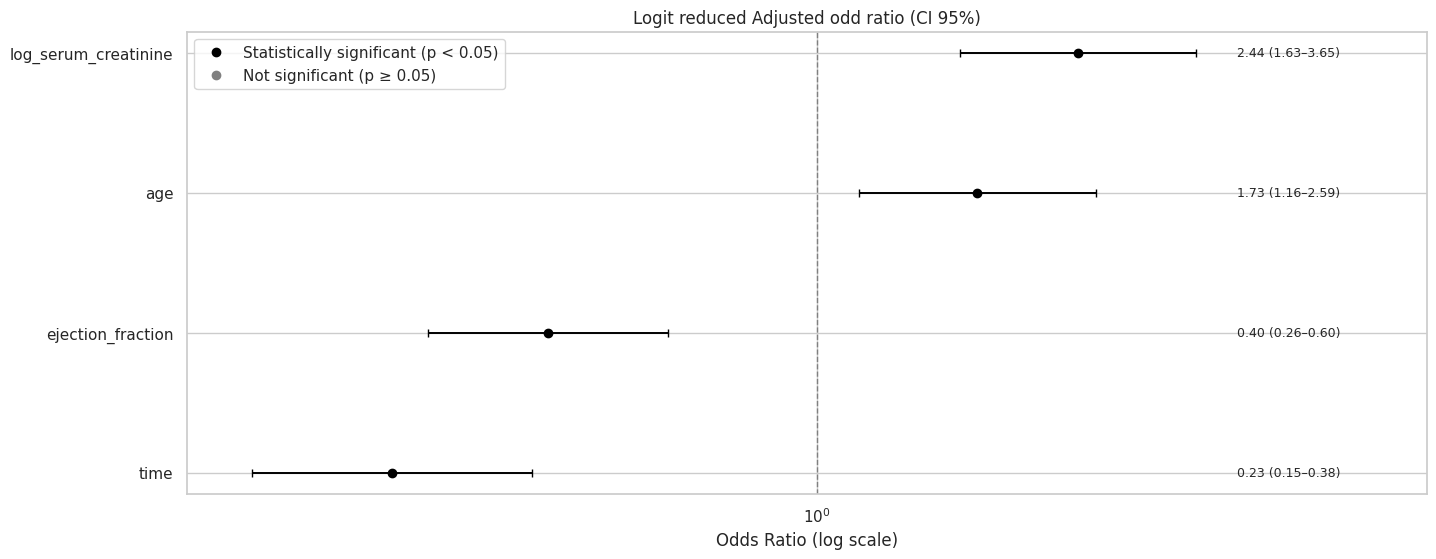

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
plot_forest_or_on_ax(axes, OR_model_reduced, title="Logit reduced Adjusted odd ratio (CI 95%)")

# 6. Model comparison with cross-validation

In [8]:
models = {
    "full": full_vars,
    "reduced": selected_vars,
    "log_transformed": log_vars,
}

cv_results = pd.DataFrame([
    {"model": name, **cross_validate_logit(X_train[cols], y_train, n_splits=5, random_state=seed)}
    for name, cols in models.items()
])

cv_results

,model,log_likelihood,AIC,pseudo_R2_McFadden,ROC-AUC,recall,precision,f1_score,brier_score
0,full,-67.505876,161.011752,0.438236,0.859669,0.639167,0.747857,0.674598,0.142423
1,reduced,-69.878021,149.756042,0.418486,0.881948,0.664167,0.740700,0.689006,0.128847
2,log_transformed,-66.877274,159.754547,0.443450,0.864158,0.651667,0.722080,0.675248,0.142053
